# **Multiple Linear Regression:**

In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv('../input/real-estate-price-prediction/Real estate.csv')
df=df.drop('No',axis=1)
print("First 5 rows of data:\n",df.head())
print("Shape:",df.shape)
print("Describe:\n",df.describe())
print("missing values:\n",df.isnull().sum())

First 5 rows of data:
    X1 transaction date  X2 house age  X3 distance to the nearest MRT station  \
0             2012.917          32.0                                84.87882   
1             2012.917          19.5                               306.59470   
2             2013.583          13.3                               561.98450   
3             2013.500          13.3                               561.98450   
4             2012.833           5.0                               390.56840   

   X4 number of convenience stores  X5 latitude  X6 longitude  \
0                               10     24.98298     121.54024   
1                                9     24.98034     121.53951   
2                                5     24.98746     121.54391   
3                                5     24.98746     121.54391   
4                                5     24.97937     121.54245   

   Y house price of unit area  
0                        37.9  
1                        42.2  
2        

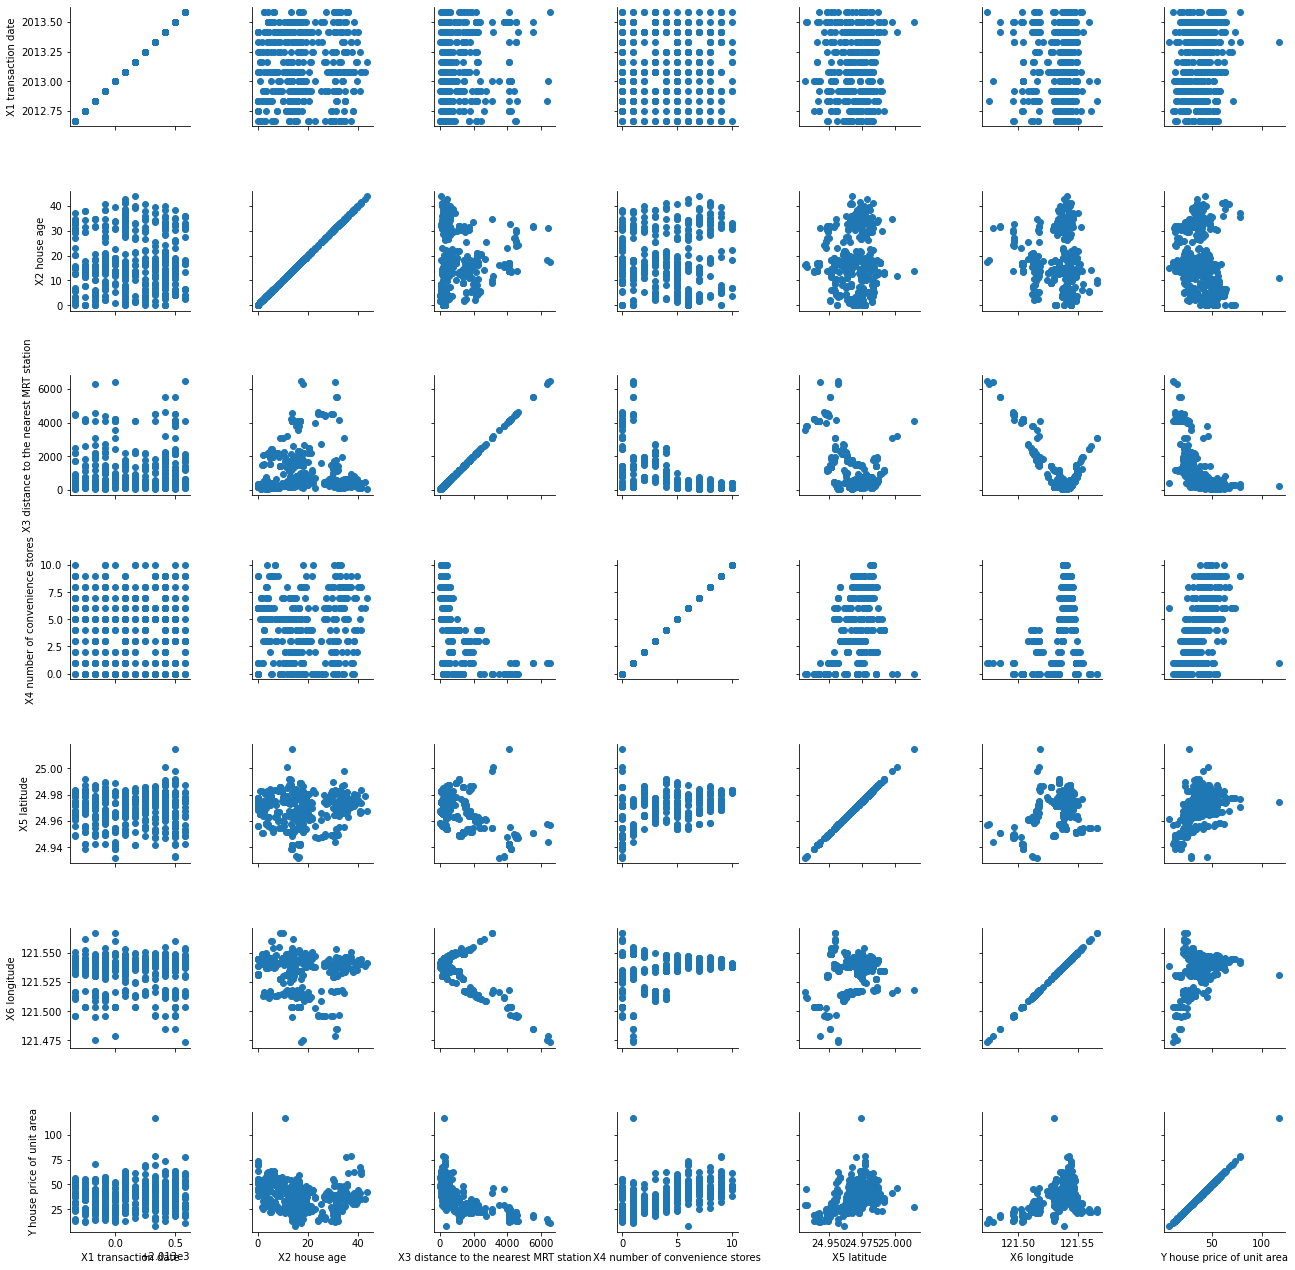

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
X=df[['X1 transaction date','X2 house age','X3 distance to the nearest MRT station',
     'X4 number of convenience stores','X5 latitude','X6 longitude']]
Y=df['Y house price of unit area']
g=sns.PairGrid(df)
g.map(plt.scatter)
plt.show()


In [3]:
import statsmodels.api as sm
X=sm.add_constant(X)
model= sm.OLS(Y,X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Y house price of unit area   R-squared:                       0.582
Model:                                    OLS   Adj. R-squared:                  0.576
Method:                         Least Squares   F-statistic:                     94.59
Date:                        Thu, 27 Aug 2020   Prob (F-statistic):           4.86e-74
Time:                                13:52:16   Log-Likelihood:                -1487.0
No. Observations:                         414   AIC:                             2988.
Df Residuals:                             407   BIC:                             3016.
Df Model:                                   6                                         
Covariance Type:                    nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                  -1.444e+04   6775.671     -2.131      0.034   -2.78e+04   -1117.421
X1 transaction date                        5.1462      1.557      3.305      0.001       2.085       8.207
X2 house age                              -0.2697      0.039     -7.000      0.000      -0.345      -0.194
X3 distance to the nearest MRT station    -0.0045      0.001     -6.250      0.000      -0.006      -0.003
X4 number of convenience stores            1.1333      0.188      6.023      0.000       0.763       1.503
X5 latitude                              225.4730     44.567      5.059      0.000     137.863     313.083
X6 longitude                             -12.4236     48.582     -0.256      0.798    -107.927      83.079
==============================================================================
Omnibus:                      231.634   Durbin-Watson:                   2.153
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3599.138
Skew:                           2.026   Prob(JB):                         0.00
Kurtosis:                      16.865   Cond. No.                     3.72e+07
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.72e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


here p value < .05 for all coefficient except X6 longitude. i.e. we reject null hypothesis at 5% level of significance. hence, there is relationship between X1 and Y,X2 andY,X3 and Y,X4 and Y,X5 and Y.there is no relationship between X6 and Y.Therefore we are discarded X6 from our model. 

In [4]:
X1=df[['X1 transaction date','X2 house age','X3 distance to the nearest MRT station',
     'X4 number of convenience stores','X5 latitude']]
X1=sm.add_constant(X1)
model1= sm.OLS(Y,X1).fit()
model1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Y house price of unit area   R-squared:                       0.582
Model:                                    OLS   Adj. R-squared:                  0.577
Method:                         Least Squares   F-statistic:                     113.8
Date:                        Thu, 27 Aug 2020   Prob (F-statistic):           4.47e-75
Time:                                13:52:16   Log-Likelihood:                -1487.0
No. Observations:                         414   AIC:                             2986.
Df Residuals:                             408   BIC:                             3010.
Df Model:                                   5                                         
Covariance Type:                    nonrobust                                         
==========================================================================================================
                                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------
const                                  -1.596e+04   3233.450     -4.936      0.000   -2.23e+04   -9602.961
X1 transaction date                        5.1348      1.555      3.303      0.001       2.079       8.191
X2 house age                              -0.2694      0.038     -7.003      0.000      -0.345      -0.194
X3 distance to the nearest MRT station    -0.0044      0.000     -8.887      0.000      -0.005      -0.003
X4 number of convenience stores            1.1361      0.188      6.056      0.000       0.767       1.505
X5 latitude                              226.8816     44.174      5.136      0.000     140.044     313.719
==============================================================================
Omnibus:                      232.810   Durbin-Watson:                   2.154
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3644.713
Skew:                           2.038   Prob(JB):                         0.00
Kurtosis:                      16.953   Cond. No.                     1.77e+07
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.77e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Our Fitted model is: Y= (-15960)+(5.1348). X1+(-0.2694) . X2 +(-0.0044) .X3 +(1.1361) . X4 +(226.8816).X5

Residual plot:



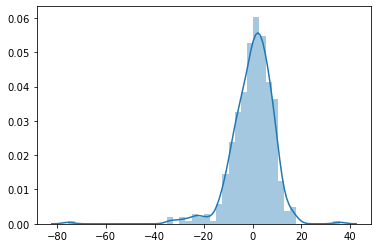

In [5]:
print("Residual plot:\n")
Y_pred=model1.predict(X1)
residual=Y_pred-Y
_=sns.distplot(residual)
plt.show()

# **RMSE (Root Mean Square Error):**

In [6]:
residual_ss=residual**2
rmse=np.sqrt(residual_ss.mean())
rmse

8.783172000243084